# How closely does MAGS track its holdings?

MAGS (Roundhill Magnificent Seven ETF) is an equal-weight basket of AAPL, AMZN,
GOOGL, META, MSFT, NVDA and TSLA, rebalanced quarterly, held through total
return swaps rather than the shares themselves, for a 0.29% expense ratio.

Swap exposure, a thin creation/redemption market in the first year and the
usual ETF bid/ask noise all let the fund drift away from the basket it is meant
to deliver. This notebook rebuilds that basket from the underlying stock prices
and measures the drift: how much return is lost per year, how noisy the fund is
day to day, and whether the exposure really is equal weight.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from yfetch import get_stock_history, get_stock_name

symbol = 'MAGS'
holdings = ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
expense_ratio = 0.0029

# Adjusted closes, so dividends count on both sides of the comparison.
# dropna() clips the stocks back to the ETF's 2023 inception.
close = pd.DataFrame({s: get_stock_history(s, period='5y', interval='1d').Close
                      for s in [symbol] + holdings}).dropna()
returns = close.pct_change().dropna()
years = (returns.index[-1] - returns.index[0]).days / 365.25

print(f'{symbol} - {get_stock_name(symbol)}')
print(f'{len(returns)} trading days, {returns.index[0]:%Y-%m-%d} .. {returns.index[-1]:%Y-%m-%d}'
      f' ({years:.1f}y)')

MAGS - Roundhill Magnificent Seven ETF
863 trading days, 2023-04-12 .. 2026-09-18 (3.4y)


In [2]:
def basket_returns(stock_returns, rebalance='Q'):
    """Daily returns of an equal-weight basket of the given stocks, reset to equal
    weights at the start of every `rebalance` period ('Q' = quarterly, like the
    MAGS index; None = reset every day).
    """
    if rebalance is None:
        return stock_returns.mean(axis=1)

    periods = stock_returns.index.tz_localize(None).to_period(rebalance)
    blocks = []
    for _, block in stock_returns.groupby(periods):
        # equal dollar weights at the block's first close, then buy and hold
        growth = (1 + block).cumprod().mean(axis=1)
        blocks.append(growth / growth.shift(1).fillna(1.0) - 1)
    return pd.concat(blocks)


def tracking_stats(fund, basket):
    """Compare a fund's daily returns against its basket's."""
    diff = fund - basket
    fund_growth, basket_growth = (1 + fund).prod(), (1 + basket).prod()
    return {
        'Fund': fund_growth - 1,
        'Basket': basket_growth - 1,
        'Gap/yr': (fund_growth / basket_growth) ** (252 / len(fund)) - 1,
        'Track err': diff.std() * np.sqrt(252),
        'Worst day': diff.abs().max(),
        'R2': fund.corr(basket) ** 2,
    }


def as_percent(df, digits=2, **other):
    """Format every column as a percentage, except the ones given a format of
    their own."""
    out = df.copy()
    for col in out.columns:
        out[col] = out[col].map((other.get(col) or f'{{:.{digits}%}}').format)
    return out


basket = basket_returns(returns[holdings])

In [3]:
# Which rebalance schedule does the fund actually behave like? The one that
# fits best is the one with the lowest tracking error against the fund.
schedules = {'daily': None, 'monthly': 'M', 'quarterly': 'Q', 'annual': 'Y'}
fit = pd.DataFrame({name: tracking_stats(returns[symbol],
                                         basket_returns(returns[holdings], r))
                    for name, r in schedules.items()}).T
fit.index.name = 'Rebalance'

print(f'{symbol} vs an equal-weight basket of {", ".join(holdings)}\n')
as_percent(fit, R2='{:.4f}')

MAGS vs an equal-weight basket of AAPL, AMZN, GOOGL, META, MSFT, NVDA, TSLA



,Fund,Basket,Gap/yr,Track err,Worst day,R2
Rebalance,,,,,,
daily,195.80%,229.60%,-3.11%,4.36%,3.31%,0.9715
monthly,195.80%,223.05%,-2.54%,4.28%,3.37%,0.9725
quarterly,195.80%,222.45%,-2.49%,4.05%,3.35%,0.9754
annual,195.80%,207.54%,-1.13%,4.93%,3.35%,0.9639


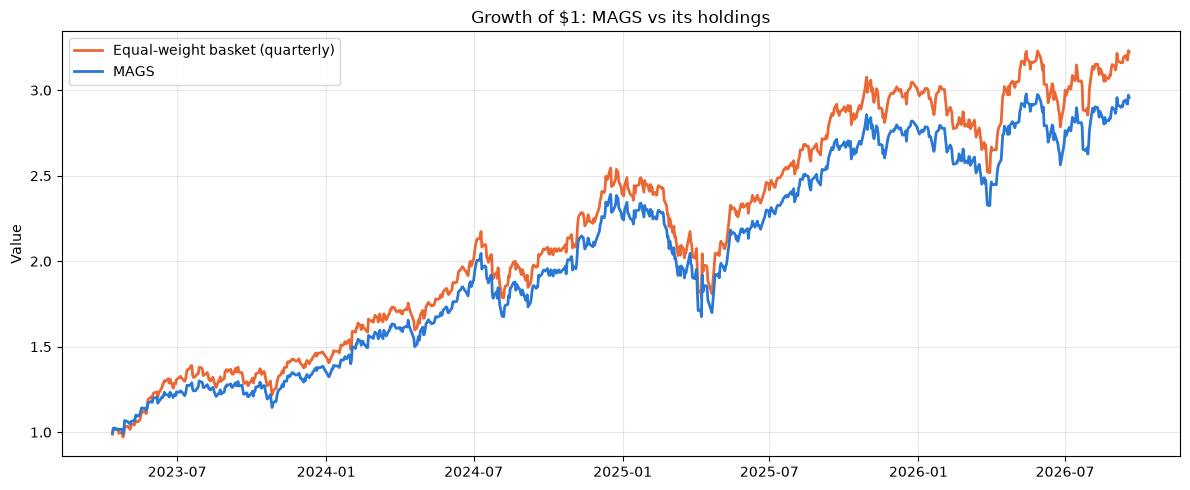

MAGS      195.80%
basket    222.45%


In [4]:
# Growth of $1 in the ETF vs in the quarterly-rebalanced basket
mags_growth = (1 + returns[symbol]).cumprod()
basket_growth = (1 + basket).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(basket_growth, color='#eb6834', lw=2, label='Equal-weight basket (quarterly)')
plt.plot(mags_growth, color='#2a78d6', lw=2, label=symbol)
plt.legend()
plt.title(f'Growth of $1: {symbol} vs its holdings')
plt.ylabel('Value')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'{symbol:8s} {mags_growth.iloc[-1] - 1:8.2%}')
print(f'{"basket":8s} {basket_growth.iloc[-1] - 1:8.2%}')

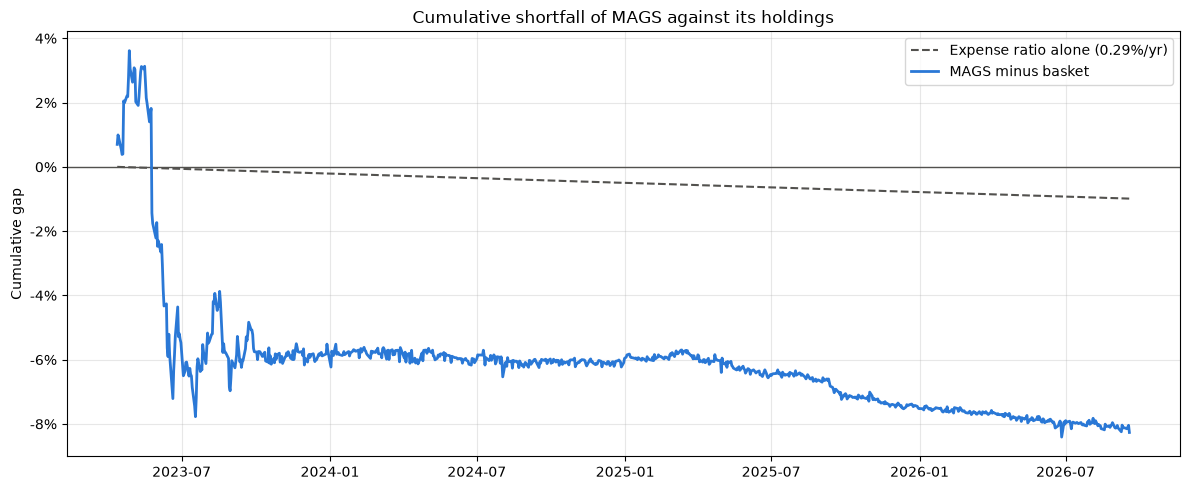

Cumulative gap      -8.27%
Annualised          -2.48%
Expense ratio       -0.29%


In [5]:
# The cumulative gap, against what the expense ratio alone would cost
gap = mags_growth / basket_growth - 1
fee_drag = (1 - expense_ratio) ** (np.arange(len(gap)) / 252) - 1

plt.figure(figsize=(12, 5))
plt.axhline(0, color='#52514e', lw=1)
plt.plot(gap.index, fee_drag, color='#52514e', lw=1.5, ls='--',
         label=f'Expense ratio alone ({expense_ratio:.2%}/yr)')
plt.plot(gap, color='#2a78d6', lw=2, label=f'{symbol} minus basket')
plt.legend()
plt.title(f'Cumulative shortfall of {symbol} against its holdings')
plt.ylabel('Cumulative gap')
plt.gca().yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Cumulative gap    {gap.iloc[-1]:8.2%}')
print(f'Annualised        {(1 + gap.iloc[-1]) ** (1 / years) - 1:8.2%}')
print(f'Expense ratio     {-expense_ratio:8.2%}')

In [6]:
# Tracking by calendar year - the fund launched thin and tightened up
diff = returns[symbol] - basket
volume = get_stock_history(symbol, period='5y').Volume
rows = {}
for year, days in diff.groupby(diff.index.year):
    rows[year] = tracking_stats(returns[symbol][days.index], basket[days.index])
    rows[year]['Volume'] = volume[days.index].mean()

by_year = pd.DataFrame(rows).T
by_year.index.name = 'Year'
as_percent(by_year, R2='{:.4f}', Volume='{:,.0f}')

,Fund,Basket,Gap/yr,Track err,Worst day,R2,Volume
Year,,,,,,,
2023,37.31%,45.62%,-7.81%,8.05%,3.35%,0.8791,"19,741"
2024,63.97%,64.41%,-0.27%,2.38%,0.55%,0.9927,"659,908"
2025,22.98%,25.07%,-1.68%,1.46%,0.49%,0.9979,"2,646,114"
2026,6.82%,7.68%,-1.12%,1.54%,0.53%,0.9955,"4,039,975"


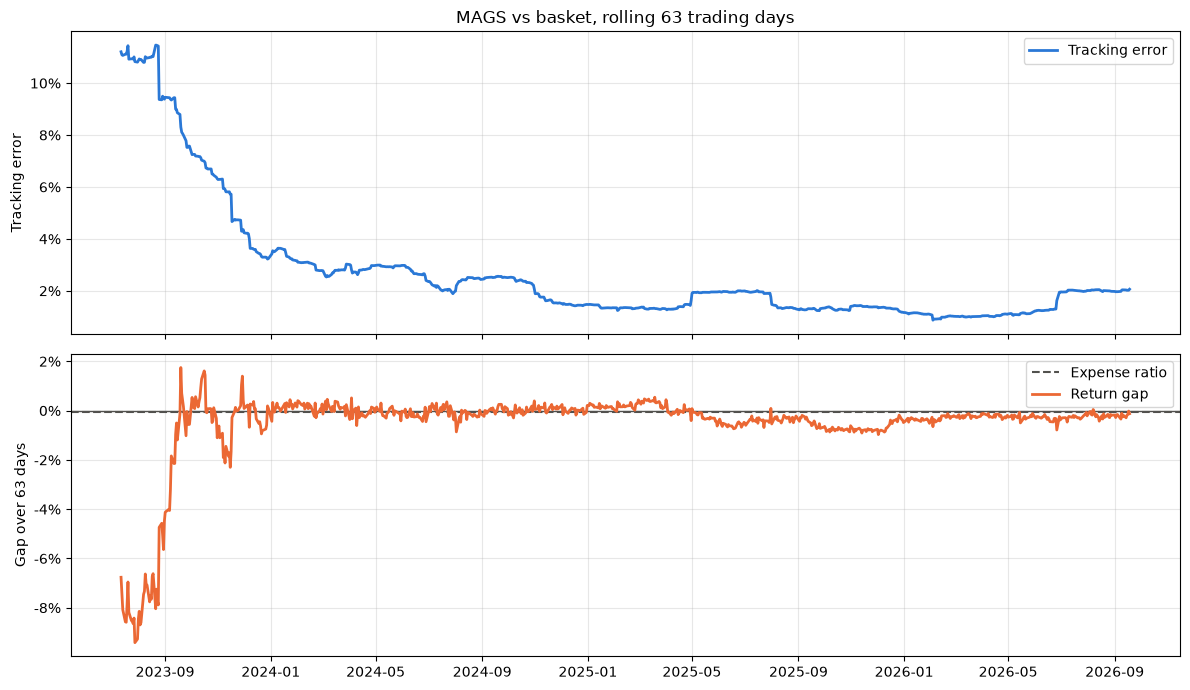

In [7]:
# Same picture day by day: rolling quarter of tracking error and of drift
window = 63  # ~one quarter of trading days
roll_te = diff.rolling(window).std() * np.sqrt(252)
roll_gap = (1 + diff).rolling(window).apply(np.prod, raw=True) - 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(roll_te, color='#2a78d6', lw=2, label='Tracking error')
ax1.set_title(f'{symbol} vs basket, rolling {window} trading days')
ax1.set_ylabel('Tracking error')
ax2.axhline(0, color='#52514e', lw=1)
ax2.axhline(-expense_ratio * window / 252, color='#52514e', lw=1.5, ls='--',
            label='Expense ratio')
ax2.plot(roll_gap, color='#eb6834', lw=2, label='Return gap')
ax2.set_ylabel(f'Gap over {window} days')
for ax in (ax1, ax2):
    ax.yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

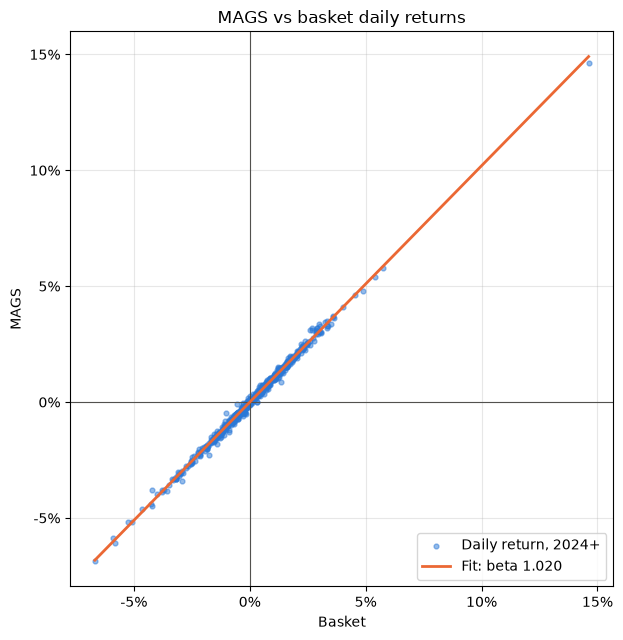

beta          1.0199
alpha/yr      -1.52%
R2            0.9955


In [8]:
# Daily returns against each other, and the days the fund went its own way
recent = returns.index.year >= 2024  # skip the illiquid launch year
slope, intercept = np.polyfit(basket[recent], returns[symbol][recent], 1)
x = np.linspace(basket[recent].min(), basket[recent].max(), 2)

plt.figure(figsize=(6.5, 6.5))
plt.axhline(0, color='#52514e', lw=0.8)
plt.axvline(0, color='#52514e', lw=0.8)
plt.scatter(basket[recent], returns[symbol][recent], s=12, alpha=0.5,
            color='#2a78d6', label='Daily return, 2024+')
plt.plot(x, slope * x + intercept, color='#eb6834', lw=2,
         label=f'Fit: beta {slope:.3f}')
plt.legend()
plt.title(f'{symbol} vs basket daily returns')
plt.xlabel('Basket')
plt.ylabel(symbol)
plt.gca().set_aspect('equal')
for axis in (plt.gca().xaxis, plt.gca().yaxis):
    axis.set_major_formatter(lambda v, _: f'{v:.0%}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'beta          {slope:.4f}')
print(f'alpha/yr      {intercept * 252:.2%}')
print(f'R2            {returns[symbol][recent].corr(basket[recent]) ** 2:.4f}')

In [9]:
# Does the gap persist, or is it bid/ask noise that reverses the next day?
print('correlation of the daily gap with itself, lagged')
for lag in range(1, 4):
    print(f'  {lag}d {diff.corr(diff.shift(lag)):7.3f}')

print('\nlargest daily gaps')
worst = pd.concat([diff.rename('Gap'), returns[symbol].rename(symbol),
                   basket.rename('Basket')], axis=1)
as_percent(worst.reindex(diff.abs().sort_values(ascending=False).index[:10]))

correlation of the daily gap with itself, lagged
  1d  -0.085
  2d  -0.052
  3d  -0.005

largest daily gaps


,Gap,MAGS,Basket
Date,,,
2023-05-25 04:00:00+00:00,-3.35%,1.23%,4.58%
2023-08-21 04:00:00+00:00,-1.68%,1.45%,3.14%
2023-04-20 04:00:00+00:00,1.61%,-0.44%,-2.05%
2023-06-20 04:00:00+00:00,-1.47%,-0.19%,1.27%
2023-06-13 04:00:00+00:00,-1.46%,-0.17%,1.29%
2023-07-03 04:00:00+00:00,-1.10%,-0.33%,0.77%
2023-08-09 04:00:00+00:00,1.03%,-1.13%,-2.16%
2023-05-05 04:00:00+00:00,-1.00%,1.49%,2.49%
2023-07-20 04:00:00+00:00,0.99%,-2.93%,-3.92%


In [10]:
# Is the exposure really equal weight? Regress the fund's daily returns on the
# seven stocks' and read off the weights the fund behaves as if it holds.
def implied_weights(rows):
    X = np.column_stack([np.ones(rows.sum()), returns[holdings][rows].values])
    coef, *_ = np.linalg.lstsq(X, returns[symbol][rows].values, rcond=None)
    return pd.Series(coef[1:], index=holdings)

weights = pd.DataFrame({'All': implied_weights(np.ones(len(returns), dtype=bool)),
                        '2024+': implied_weights(recent)})
weights.loc['Total'] = weights.sum()
print(f'equal weight = {1 / len(holdings):.2%}\n')
as_percent(weights)

equal weight = 14.29%



,All,2024+
AAPL,14.03%,13.54%
AMZN,16.07%,14.65%
GOOGL,15.68%,15.31%
META,15.39%,14.85%
MSFT,14.13%,13.88%
NVDA,13.04%,15.59%
TSLA,12.63%,13.84%
Total,100.97%,101.68%


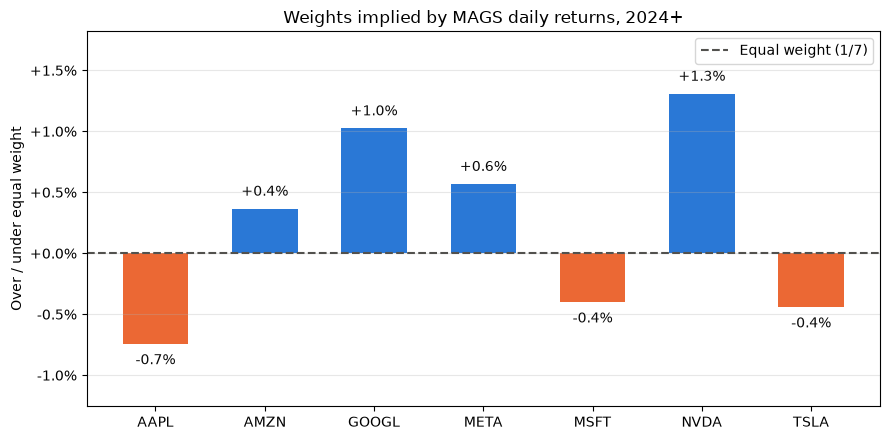

In [11]:
# How far each one sits from the 1/7 the index calls for
tilt = weights['2024+'][:-1] - 1 / len(holdings)

plt.figure(figsize=(9, 4.5))
plt.axhline(0, color='#52514e', lw=1.5, ls='--', label='Equal weight (1/7)')
plt.bar(tilt.index, tilt, width=0.6,
        color=['#2a78d6' if t >= 0 else '#eb6834' for t in tilt])
for stock, t in tilt.items():
    plt.text(stock, t + (0.0008 if t >= 0 else -0.0008), f'{t:+.1%}',
             ha='center', va='bottom' if t >= 0 else 'top', color='#0b0b0b')
plt.legend()
plt.title(f'Weights implied by {symbol} daily returns, 2024+')
plt.ylabel('Over / under equal weight')
plt.gca().yaxis.set_major_formatter(lambda y, _: f'{y:+.1%}')
plt.margins(y=0.25)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## What the numbers say

**It is the right basket, but an expensive wrapper.** Quarterly rebalancing fits
best of the schedules tried, and the implied weights land within ~1pp of 1/7
each, so MAGS really is delivering equal-weight Magnificent Seven exposure. The
weights sum to 101.7% and beta is 1.02 - the swaps run a touch hot, not enough
to matter.

**Tracking has improved enormously.** In the 2023 launch year, on ~20k shares a
day, R2 was 0.88 and tracking error 8%/yr - the closing price was often just
stale. By 2025-26, on millions of shares a day, R2 is 0.996-0.998 and tracking
error is ~1.5%/yr. Every one of the ten worst daily gaps is from 2023.

**What is left is noise, not lag.** The daily gap correlates -0.085 with itself
one day later: it reverses rather than persists, which is bid/ask and
closing-auction noise around a correct price, not the fund drifting behind its
holdings.

**The cost is real and well above the headline fee.** Since inception MAGS
returned 195.8% against the basket's 222.5% - an 8.3% cumulative shortfall,
2.5%/yr. Most of that was dug in during 2023, and 2024 tracked almost exactly
flat, but from mid-2025 the fund bleeds a steady 1.1-1.7%/yr against its
holdings, versus a 0.29% expense ratio. Swap financing is the obvious suspect:
the counterparty charges a rate on the notional, which does not show up in the
expense ratio.

**Caveat:** the basket here is built from closing prices and assumes the index
rebalances on calendar quarter boundaries. The real index has its own
rebalance dates and MAGS holds swaps, not shares, so a small part of the gap is
this approximation rather than a genuine cost.